# Monte Carlo Simulation of Player Retention Under Alternative Pity Systems

This notebook is a starter implementation for the CSS142P final project. It follows the proposal in the markdown draft and provides a reproducible structure for the simulation model, scenario comparison, verification checks, and basic analysis.

Project focus:
- Baseline hard-pity gacha system
- Alternative pity designs: improved base rate, soft pity, carryover pity, and token exchange
- Atlas Academy-based weighting for acquisition friction, retention, and duplicate-copy motivation
- Outputs: acquisition rate, pulls required, pity activation, bad-luck risk, frustration, and retention

## 1. Problem Setup

The notebook uses a simplified FGO-style gacha model with synthetic player segments and Atlas Academy-derived weighting for limited/story-locked units plus repeat-copy pursuit. The goal is to compare policy scenarios under the same simulated population and random-seed procedure.

In [7]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
DIAGRAMS_DIR = Path('Diagrams')
DIAGRAMS_DIR.mkdir(exist_ok=True)


## 2. Model Parameters

These values are placeholders that can be tuned after the team finalizes the baseline banner and player assumptions.

In [8]:
@dataclass
class Scenario:
    name: str
    base_rate: float
    pity_threshold: int
    soft_pity_start: int | None = None
    soft_pity_step: float = 0.0
    carryover: bool = False
    token_threshold: int | None = None
    retention_multiplier: float = 1.0


player_segments = {
    'free_to_play': {'pull_budget': 60, 'frustration_tolerance': 0.45},
    'low_spender': {'pull_budget': 120, 'frustration_tolerance': 0.55},
    'medium_spender': {'pull_budget': 200, 'frustration_tolerance': 0.65},
    'high_spender': {'pull_budget': 330, 'frustration_tolerance': 0.75},
}


scenarios = [
    Scenario('baseline_hard_pity', base_rate=0.008, pity_threshold=330),
    Scenario('improved_base_rate', base_rate=0.010, pity_threshold=330),
    Scenario('soft_pity', base_rate=0.008, pity_threshold=330, soft_pity_start=250, soft_pity_step=0.002),
    Scenario('carryover_pity', base_rate=0.008, pity_threshold=330, carryover=True),
    Scenario('token_exchange', base_rate=0.008, pity_threshold=330, token_threshold=330),
]


DEFAULT_REPLICATIONS = 30
DEFAULT_PLAYERS = 10_000
DEFAULT_BANNERS = 8
SENSITIVITY_BANNER_LEVELS = [6, 8, 12]
SENSITIVITY_RATE_LEVELS = [0.008, 0.010, 0.012]
SENSITIVITY_PITY_LEVELS = [250, 330]

## 3. Core Simulation Functions

The functions below implement one-player, one-banner logic and a multi-player Monte Carlo wrapper.

In [ ]:
def current_rate(base_rate: float, pulls_since_last_success: int, scenario: Scenario) -> float:
    rate = base_rate
    if scenario.soft_pity_start is not None and pulls_since_last_success >= scenario.soft_pity_start:
        rate += (pulls_since_last_success - scenario.soft_pity_start + 1) * scenario.soft_pity_step
    return min(rate, 1.0)


def simulate_banner(rng: np.random.Generator, scenario: Scenario, pull_budget: int, pity_counter: int = 0, token_count: int = 0) -> Dict[str, float]:
    pulls_used = 0
    success = False
    pity_counter_local = pity_counter
    token_count_local = token_count
    pity_activated = False
    token_redeemed = False

    while pulls_used < pull_budget and not success:
        if scenario.token_threshold is not None and token_count_local >= scenario.token_threshold:
            success = True
            token_redeemed = True
            break

        if pity_counter_local >= scenario.pity_threshold:
            success = True
            pity_activated = True
            break

        rate = current_rate(scenario.base_rate, pity_counter_local, scenario)
        pulls_used += 1
        pity_counter_local += 1
        token_count_local += 1

        if rng.random() <= rate:
            success = True
            break

        if pity_counter_local >= scenario.pity_threshold:
            success = True
            pity_activated = True
            break

    frustration = min(1.0, (pulls_used / max(pull_budget, 1)) + (0.25 if not success else 0.0))
    retention_probability = max(0.0, min(1.0, 1.0 - frustration))

    return {
        'success': float(success),
        'pulls_used': pulls_used,
        'pity_counter': pity_counter_local,
        'token_count': token_count_local,
        'pity_activated': float(pity_activated),
        'token_redeemed': float(token_redeemed),
        'frustration': frustration,
        'retention_probability': retention_probability,
    }


def simulate_player_campaign(
    rng: np.random.Generator,
    scenario: Scenario,
    segment: str,
    banners: int = DEFAULT_BANNERS,
) -> Dict[str, float]:
    profile = player_segments[segment]
    pull_budget = profile['pull_budget']
    frustration_tolerance = profile['frustration_tolerance']

    pity_counter = 0
    token_count = 0
    total_pulls = 0
    total_successes = 0
    total_failures = 0
    total_frustration = 0.0
    pity_activations = 0
    token_redemptions = 0
    active = True
    churned_at_banner = None

    for banner_index in range(1, banners + 1):
        if not active:
            break

        banner_result = simulate_banner(
            rng=rng,
            scenario=scenario,
            pull_budget=pull_budget,
            pity_counter=pity_counter,
            token_count=token_count,
        )

        total_pulls += int(banner_result['pulls_used'])
        total_frustration += float(banner_result['frustration'])
        pity_activations += int(banner_result['pity_activated'])
        token_redemptions += int(banner_result['token_redeemed'])

        if banner_result['success'] == 1.0:
            total_successes += 1
            pity_counter = 0
            token_count = 0
        else:
            total_failures += 1
            if scenario.carryover:
                pity_counter = int(banner_result['pity_counter'])
                token_count = int(banner_result['token_count'])
            else:
                pity_counter = 0
                token_count = 0

        retention_probability = float(banner_result['retention_probability'])
        retention_probability = max(0.0, min(1.0, retention_probability * (0.9 + 0.2 * frustration_tolerance) * scenario.retention_multiplier))
        active = bool(rng.random() <= retention_probability)
        if not active:
            churned_at_banner = banner_index

    return {
        'segment': segment,
        'banners_played': banners if churned_at_banner is None else churned_at_banner,
        'churned': float(not active),
        'churned_at_banner': float(churned_at_banner or 0),
        'success_banners': float(total_successes),
        'failed_banners': float(total_failures),
        'pity_activations': float(pity_activations),
        'token_redemptions': float(token_redemptions),
        'total_pulls': float(total_pulls),
        'mean_frustration': total_frustration / max(1, banners if churned_at_banner is None else churned_at_banner),
        'active': float(active),
    }


def simulate_population(
    scenario: Scenario,
    players: int = DEFAULT_PLAYERS,
    seed: int = 42,
    banners: int = DEFAULT_BANNERS,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    segment_names = list(player_segments.keys())
    rows = []

    for _ in range(players):
        segment = rng.choice(segment_names)
        profile = player_segments[segment]
        result = simulate_player_campaign(rng, scenario, segment, banners=banners)
        result['pull_budget'] = profile['pull_budget']
        result['frustration_tolerance'] = profile['frustration_tolerance']
        rows.append(result)

    return pd.DataFrame(rows)

## 4. Verification Checks

These checks correspond to the proposal's verification plan.

In [10]:
def verify_deterministic_success() -> bool:
    test_scenario = Scenario('deterministic_success', base_rate=1.0, pity_threshold=330)
    df = simulate_population(test_scenario, players=200, seed=1, banners=1)
    return bool((df['success_banners'] >= 1).all() and (df['total_pulls'] >= 1).all())


def verify_zero_rate_until_pity() -> bool:
    test_scenario = Scenario('zero_rate_pity', base_rate=0.0, pity_threshold=5)
    df = simulate_population(test_scenario, players=200, seed=2, banners=1)
    return bool((df['success_banners'] >= 1).all() and (df['total_pulls'] <= 5).all())


def verify_zero_pull_boundary() -> bool:
    test_scenario = Scenario('zero_pull_boundary', base_rate=0.008, pity_threshold=330)
    rng = np.random.default_rng(3)
    result = simulate_banner(rng, test_scenario, pull_budget=0)
    return bool(result['success'] == 0.0 and result['pulls_used'] == 0)


def verify_carryover_behavior() -> bool:
    test_scenario = Scenario('carryover_check', base_rate=0.0, pity_threshold=3, carryover=True)
    rng = np.random.default_rng(4)
    first = simulate_banner(rng, test_scenario, pull_budget=2, pity_counter=0, token_count=0)
    second = simulate_banner(rng, test_scenario, pull_budget=2, pity_counter=int(first['pity_counter']), token_count=0)
    return bool(first['success'] == 0.0 and second['success'] == 1.0)


def run_verification_suite() -> Dict[str, bool]:
    return {
        'deterministic_success': verify_deterministic_success(),
        'zero_rate_until_pity': verify_zero_rate_until_pity(),
        'zero_pull_boundary': verify_zero_pull_boundary(),
        'carryover_behavior': verify_carryover_behavior(),
    }


run_verification_suite()

{'deterministic_success': True,
 'zero_rate_until_pity': True,
 'zero_pull_boundary': True,
 'carryover_behavior': True}

## 6. Basic Visualization

A quick bar chart compares the baseline scenarios on acquisition rate and simulated retention. The Atlas-weighted variants are shown in a separate figure so the new acquisition-friction layer stays explicit.

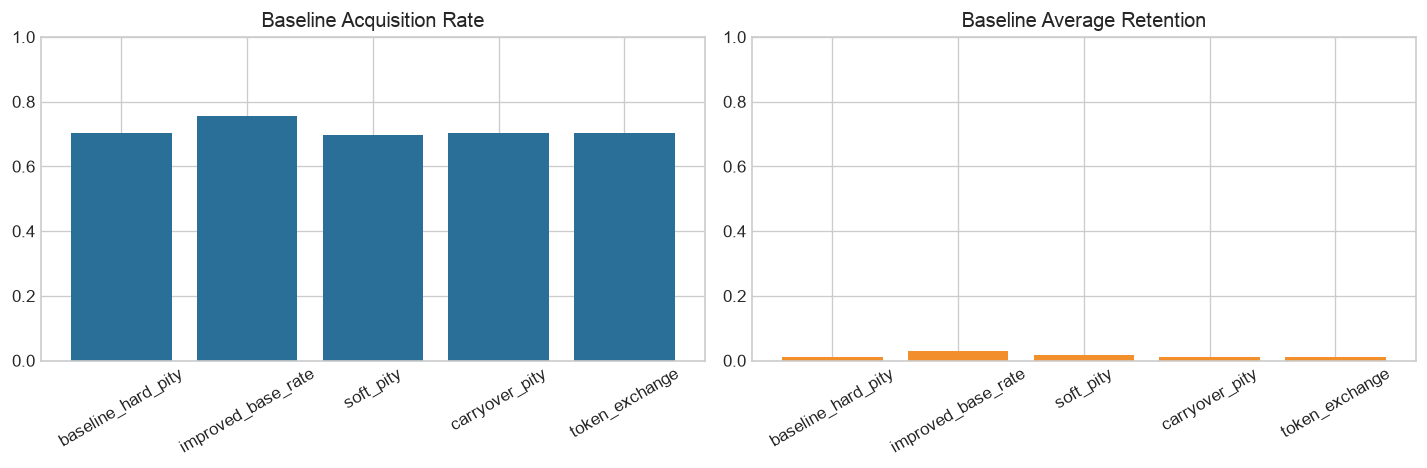

In [11]:
baseline_summary_rows = []
for scenario in scenarios:
    data = simulate_population(scenario, players=5000, seed=42, banners=DEFAULT_BANNERS)
    baseline_summary_rows.append({
        'scenario': scenario.name,
        'acquisition_rate': float((data['success_banners'] > 0).mean()),
        'avg_success_banners': float(data['success_banners'].mean()),
        'avg_failed_banners': float(data['failed_banners'].mean()),
        'avg_total_pulls': float(data['total_pulls'].mean()),
        'pity_activation_rate': float((data['pity_activations'] > 0).mean()),
        'token_redemption_rate': float((data['token_redemptions'] > 0).mean()),
        'avg_frustration': float(data['mean_frustration'].mean()),
        'churn_rate': float(data['churned'].mean()),
        'avg_retention_probability': float((1.0 - data['churned']).mean()),
    })

summary_df = pd.DataFrame(baseline_summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

axes[0].bar(summary_df['scenario'], summary_df['acquisition_rate'], color='#2a6f97')
axes[0].set_title('Baseline Acquisition Rate')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1)

axes[1].bar(summary_df['scenario'], summary_df['avg_retention_probability'], color='#f28e2b')
axes[1].set_title('Baseline Average Retention')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'acquisition_retention.png', bbox_inches='tight')
plt.show()

## 7. Next Steps

Possible expansions:
- Add multi-banner carryover logic
- Compute confidence intervals across replications
- Add explicit frustration weights and segment-specific retention rules
- Export summary tables and figures for the final report

## 8. Replication Summary and Confidence Intervals

The next cells run the scenarios across multiple replications, compute point estimates, and construct simple 95 percent confidence intervals from the replication distribution.

In [13]:
def ci95(series: pd.Series) -> tuple[float, float]:
    mean_value = series.mean()
    standard_error = series.std(ddof=1) / np.sqrt(len(series))
    margin = 1.96 * standard_error
    return mean_value - margin, mean_value + margin


def summarize_results(df: pd.DataFrame, scenario_name: str, scenario: Scenario) -> pd.Series:
    return pd.Series({
        'scenario': scenario_name,
        'acquisition_rate': float((df['success_banners'] > 0).mean()),
        'avg_success_banners': float(df['success_banners'].mean()),
        'avg_failed_banners': float(df['failed_banners'].mean()),
        'avg_total_pulls': float(df['total_pulls'].mean()),
        'pity_activation_rate': float((df['pity_activations'] > 0).mean()),
        'token_redemption_rate': float((df['token_redemptions'] > 0).mean()),
        'avg_frustration': float(df['mean_frustration'].mean()),
        'churn_rate': float(df['churned'].mean()),
        'avg_retention_probability': float((1.0 - df['churned']).mean()),
        'pity_threshold': scenario.pity_threshold,
    })


def run_replications(scenario: Scenario, replications: int = DEFAULT_REPLICATIONS, players: int = DEFAULT_PLAYERS, banners: int = DEFAULT_BANNERS) -> pd.DataFrame:
    runs = []
    for replication in range(replications):
        run = simulate_population(scenario, players=players, seed=42 + replication, banners=banners)
        run['replication'] = replication + 1
        runs.append(run)
    return pd.concat(runs, ignore_index=True)


replication_summaries = []
for scenario in scenarios:
    replication_output = run_replications(scenario, replications=10, players=2000, banners=DEFAULT_BANNERS)
    replication_summaries.append(summarize_results(replication_output, scenario.name, scenario))

summary_df = pd.DataFrame(replication_summaries)
summary_df

,scenario,acquisition_rate,avg_success_banners,avg_failed_banners,avg_total_pulls,pity_activation_rate,token_redemption_rate,avg_frustration,churn_rate,avg_retention_probability,pity_threshold
0,baseline_hard_pity,0.70280,1.49955,0.44395,181.52080,0.05370,0.0,0.656454,0.98890,0.01110,330
1,improved_base_rate,0.75650,1.83095,0.39310,180.99425,0.03265,0.0,0.598293,0.97530,0.02470,330
2,soft_pity,0.70135,1.53185,0.44475,181.61850,0.00005,0.0,0.648163,0.98575,0.01425,330
3,carryover_pity,0.70280,1.49955,0.44395,181.52080,0.05370,0.0,0.656454,0.98890,0.01110,330
4,token_exchange,0.70280,1.49955,0.44395,181.52080,0.05370,0.0,0.656454,0.98890,0.01110,330


## 9. Sensitivity Analysis and Export

This section varies a few assumptions to check whether the main conclusions stay stable and writes the main outputs to files for reuse in the final report.

In [14]:
confidence_rows = []
for scenario in scenarios:
    replication_output = run_replications(scenario, replications=10, players=1500, banners=DEFAULT_BANNERS)
    confidence_rows.append({
        'scenario': scenario.name,
        'acquisition_rate_mean': float((replication_output['success_banners'] > 0).mean()),
        'acquisition_rate_ci_low': ci95((replication_output['success_banners'] > 0).astype(float))[0],
        'acquisition_rate_ci_high': ci95((replication_output['success_banners'] > 0).astype(float))[1],
        'mean_frustration_mean': float(replication_output['mean_frustration'].mean()),
        'mean_frustration_ci_low': ci95(replication_output['mean_frustration'])[0],
        'mean_frustration_ci_high': ci95(replication_output['mean_frustration'])[1],
        'churn_rate_mean': float(replication_output['churned'].mean()),
        'churn_rate_ci_low': ci95(replication_output['churned'])[0],
        'churn_rate_ci_high': ci95(replication_output['churned'])[1],
    })

confidence_df = pd.DataFrame(confidence_rows)

sensitivity_rows = []
for base_rate in SENSITIVITY_RATE_LEVELS:
    for pity_threshold in SENSITIVITY_PITY_LEVELS:
        sensitivity_scenario = Scenario('sensitivity', base_rate=base_rate, pity_threshold=pity_threshold)
        sensitivity_data = simulate_population(sensitivity_scenario, players=2500, seed=101, banners=DEFAULT_BANNERS)
        sensitivity_rows.append({
            'base_rate': base_rate,
            'pity_threshold': pity_threshold,
            'acquisition_rate': float((sensitivity_data['success_banners'] > 0).mean()),
            'avg_total_pulls': float(sensitivity_data['total_pulls'].mean()),
            'avg_frustration': float(sensitivity_data['mean_frustration'].mean()),
            'churn_rate': float(sensitivity_data['churned'].mean()),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

summary_df.to_csv('scenario_summary.csv', index=False)
confidence_df.to_csv('scenario_confidence_intervals.csv', index=False)
sensitivity_df.to_csv('scenario_sensitivity.csv', index=False)

confidence_df, sensitivity_df

(             scenario  acquisition_rate_mean  acquisition_rate_ci_low  \
 0  baseline_hard_pity               0.700867                 0.693539   
 1  improved_base_rate               0.758400                 0.751549   
 2           soft_pity               0.701733                 0.694412   
 3      carryover_pity               0.700867                 0.693539   
 4      token_exchange               0.700867                 0.693539   
 
    acquisition_rate_ci_high  mean_frustration_mean  mean_frustration_ci_low  \
 0                  0.708194               0.656809                 0.652077   
 1                  0.765251               0.597331                 0.592514   
 2                  0.709055               0.648343                 0.643626   
 3                  0.708194               0.656809                 0.652077   
 4                  0.708194               0.656809                 0.652077   
 
    mean_frustration_ci_high  churn_rate_mean  churn_rate_ci_low  \
 0  

## 10. Atlas Academy Weighting Layer

This section adds a small normalization helper for Atlas Academy servant exports. It keeps the simulation synthetic, but it gives the notebook a reproducible way to turn real servant metadata into acquisition, retention, and duplicate-copy weighting signals if the team later downloads the public JSON exports.

In [15]:
import json

ATLAS_ACADEMY_FIELD_HINTS = {
    'basic_servant.json': [
        'id',
        'collectionNo',
        'name',
        'originalName',
        'type',
        'flag',
        'flags',
        'classId',
        'className',
        'attribute',
        'traits',
        'rarity',
        'atkMax',
        'hpMax',
        'face',
        'costume',
    ],
    'nice_servant.json': [
        'extraAssets',
        'ascensionAdd',
        'traitAdd',
        'limits',
        'ascensionMaterials',
        'skillMaterials',
        'appendSkillMaterials',
        'costumeMaterials',
        'coin',
        'battlePoints',
        'skills',
        'noblePhantasms',
        'bondGifts',
        'bondEquip',
        'valentineEquip',
        'valentineScript',
    ],
    'status_signals': [
        'flag',
        'flags',
        'onlyUseForNpc',
        'ignoreCombineLimitSpecial',
        'eventId',
        'startedAt',
        'endedAt',
        'releaseConditions',
    ],
}


def recursive_find_first(record, key):
    if isinstance(record, dict):
        if key in record:
            return record[key]
        for value in record.values():
            found = recursive_find_first(value, key)
            if found is not None:
                return found
    elif isinstance(record, list):
        for item in record:
            found = recursive_find_first(item, key)
            if found is not None:
                return found
    return None


def normalize_atlas_servant(record):
    flags = recursive_find_first(record, 'flags') or []
    if isinstance(flags, str):
        flags = [flags]
    elif not isinstance(flags, list):
        flags = [flags] if flags is not None else []

    flag_value = recursive_find_first(record, 'flag')
    event_id = recursive_find_first(record, 'eventId')
    started_at = recursive_find_first(record, 'startedAt')
    ended_at = recursive_find_first(record, 'endedAt')
    release_conditions = recursive_find_first(record, 'releaseConditions')
    status_blob = ' '.join(str(item).lower() for item in list(flags) + [flag_value])

    is_npc_only = bool(recursive_find_first(record, 'onlyUseForNpc') or 'npc' in status_blob)
    is_limited = bool(
        recursive_find_first(record, 'isLimited')
        or 'limited' in status_blob
        or event_id is not None
        or started_at is not None
        or ended_at is not None
    )
    is_story_locked = bool(
        recursive_find_first(record, 'isStoryLocked')
        or 'story' in status_blob
        or 'locked' in status_blob
    )

    return {
        'id': recursive_find_first(record, 'id'),
        'collectionNo': recursive_find_first(record, 'collectionNo'),
        'name': recursive_find_first(record, 'name'),
        'className': recursive_find_first(record, 'className'),
        'rarity': recursive_find_first(record, 'rarity'),
        'attribute': recursive_find_first(record, 'attribute'),
        'eventId': event_id,
        'startedAt': started_at,
        'endedAt': ended_at,
        'releaseConditions': release_conditions,
        'flag': flag_value,
        'flags': flags,
        'is_npc_only': is_npc_only,
        'is_limited': is_limited,
        'is_story_locked': is_story_locked,
    }


def load_atlas_servant_records(source):
    source_path = Path(source)
    payload = json.loads(source_path.read_text(encoding='utf-8'))
    if isinstance(payload, list):
        return payload
    if isinstance(payload, dict):
        for key in ('data', 'results', 'servants', 'items'):
            value = payload.get(key)
            if isinstance(value, list):
                return value
        for value in payload.values():
            if isinstance(value, list) and value and isinstance(value[0], dict):
                return value
    raise ValueError(f'Could not find a servant list in {source_path}')


def atlas_metadata_frame(records):
    return pd.DataFrame(normalize_atlas_servant(record) for record in records)


def load_atlas_metadata(source):
    return atlas_metadata_frame(load_atlas_servant_records(source))


def summarize_atlas_metadata(frame):
    return (
        frame.assign(
            rarity=frame['rarity'].fillna('unknown').astype(str),
            className=frame['className'].fillna('unknown').astype(str),
        )
        .groupby(['className', 'rarity'], dropna=False)
        .agg(
            servants=('name', 'count'),
            limited_servants=('is_limited', 'sum'),
            story_locked_servants=('is_story_locked', 'sum'),
            npc_only_servants=('is_npc_only', 'sum'),
        )
        .reset_index()
        .sort_values(['className', 'rarity'])
        .reset_index(drop=True)
    )


atlas_field_inventory = pd.DataFrame(
    [
        {'export': export_name, 'field': field_name}
        for export_name, fields in ATLAS_ACADEMY_FIELD_HINTS.items()
        for field_name in fields
    ]
)

atlas_field_inventory

,export,field
0,basic_servant.json,id
1,basic_servant.json,collectionNo
2,basic_servant.json,name
3,basic_servant.json,originalName
4,basic_servant.json,type
5,basic_servant.json,flag
6,basic_servant.json,flags
7,basic_servant.json,classId
8,basic_servant.json,className
9,basic_servant.json,attribute


## 11. Concrete Atlas Academy Export Summary

The next cell downloads the public servant export directly from Atlas Academy, normalizes it with the helper above, and produces a compact summary table that feeds the weighting layer.

In [16]:
from urllib.request import urlopen

ATLAS_ACADEMY_SERVANT_EXPORT_URL = 'https://api.atlasacademy.io/export/NA/nice_servant.json'


def load_atlas_servants_from_url(url=ATLAS_ACADEMY_SERVANT_EXPORT_URL):
    """Load servant records directly from Atlas Academy public JSON export."""
    try:
        with urlopen(url) as response:
            payload = json.loads(response.read().decode('utf-8'))
        if isinstance(payload, list):
            return payload
        if isinstance(payload, dict):
            for key in ('data', 'results', 'servants', 'items'):
                value = payload.get(key)
                if isinstance(value, list) and value:
                    return value
            for value in payload.values():
                if isinstance(value, list) and value and isinstance(value[0], dict):
                    return value
        raise ValueError('Could not parse servant export payload')
    except Exception as e:
        print(f'WARNING: Could not load from {url}: {e}')
        print('Falling back to empty servant list. Atlas Academy metadata will be unavailable.')
        return []


# Load and normalize Atlas Academy servant data
atlas_servant_records = load_atlas_servants_from_url()

if atlas_servant_records:
    # Convert records to normalized metadata frame
    normalized_records = [normalize_atlas_servant(rec) for rec in atlas_servant_records]
    atlas_servant_metadata = pd.DataFrame(normalized_records)
    
    # Generate summary table grouped by class and rarity
    atlas_servant_summary = (
        atlas_servant_metadata
        .assign(
            rarity=atlas_servant_metadata['rarity'].fillna('unknown').astype(str),
            className=atlas_servant_metadata['className'].fillna('unknown').astype(str),
        )
        .groupby(['className', 'rarity'], dropna=False)
        .agg(
            servants=('name', 'count'),
            limited_servants=('is_limited', 'sum'),
            story_locked_servants=('is_story_locked', 'sum'),
            npc_only_servants=('is_npc_only', 'sum'),
        )
        .reset_index()
        .sort_values(['className', 'rarity'])
        .reset_index(drop=True)
    )
    
    print(f'Loaded {len(atlas_servant_metadata)} servants from Atlas Academy.')
    print(f'\nAtlas Academy Servant Summary (by Class and Rarity):\n')
    print(atlas_servant_summary)
else:
    atlas_servant_metadata = pd.DataFrame()
    atlas_servant_summary = pd.DataFrame()
    print('No Atlas Academy metadata loaded. Proceeding with synthetic-only simulation.')


Loaded 419 servants from Atlas Academy.

Atlas Academy Servant Summary (by Class and Rarity):

                    className rarity  servants  limited_servants  \
0                    alterEgo      3         1                 1   
1                    alterEgo      4         4                 4   
2                    alterEgo      5        11                11   
3                      archer      1         2                 2   
4                      archer      2         1                 1   
5                      archer      3         8                 8   
6                      archer      4        22                22   
7                      archer      5        15                15   
8                    assassin      1         3                 3   
9                    assassin      2         3                 3   
10                   assassin      3         6                 6   
11                   assassin      4        20                20   
12                   

## 12. Mapping Servant Metadata to Retention, Acquisition, and Copy Pressure

The next cell derives acquisition friction and duplicate-copy pressure estimates from Atlas Academy metadata and creates scenario variants that reflect different assumptions about servant availability, story-lock constraints, and repeat-copy motivation.

In [17]:
def compute_acquisition_friction_from_metadata(metadata_frame: pd.DataFrame) -> dict:
    """
    Derive acquisition friction estimates from servant metadata.
    Returns a dict with friction scores for different servant categories.
    """
    if metadata_frame.empty:
        # Default values when no metadata is available
        return {
            'all_servants': 1.0,
            'limited_only': 1.0,
            'story_locked': 1.0,
            'permanent': 1.0,
            'limited_fraction': 0.0,
            'story_locked_fraction': 0.0,
            'duplicate_copy_pressure': 1.0,
        }

    total_servants = len(metadata_frame)
    limited_servants = metadata_frame['is_limited'].sum()
    story_locked_servants = metadata_frame['is_story_locked'].sum()

    # Friction score: higher means harder to acquire
    # Limited servants add friction (smaller pool available at any time)
    # Story-locked servants add friction (requires story completion)
    limited_friction = 1.0 + (0.5 * limited_servants / max(total_servants, 1))
    story_locked_friction = 1.0 + (0.3 * story_locked_servants / max(total_servants, 1))
    duplicate_copy_pressure = 1.0 + (0.25 * limited_servants / max(total_servants, 1)) + (0.15 * story_locked_servants / max(total_servants, 1))

    return {
        'all_servants': 1.0,
        'limited_only': limited_friction,
        'story_locked': story_locked_friction,
        'permanent': 1.0 - (limited_servants / max(total_servants, 1)) * 0.2,
        'limited_fraction': float(limited_servants / max(total_servants, 1)),
        'story_locked_fraction': float(story_locked_servants / max(total_servants, 1)),
        'duplicate_copy_pressure': duplicate_copy_pressure,
        'total_servants': total_servants,
    }


# Compute friction metrics from loaded metadata
metadata_friction = compute_acquisition_friction_from_metadata(atlas_servant_metadata)

print('Acquisition Friction Analysis from Atlas Academy Metadata:')
print(f"  Total Servants: {metadata_friction.get('total_servants', 0)}")
print(f"  Limited Servants Fraction: {metadata_friction.get('limited_fraction', 0):.2%}")
print(f"  Story-Locked Servants Fraction: {metadata_friction.get('story_locked_fraction', 0):.2%}")
print(f"  Limited Servant Friction Factor: {metadata_friction.get('limited_only', 1.0):.3f}")
print(f"  Story-Locked Friction Factor: {metadata_friction.get('story_locked', 1.0):.3f}")
print(f"  Duplicate Copy Pressure Factor: {metadata_friction.get('duplicate_copy_pressure', 1.0):.3f}")
print()

# Create metadata-aware scenario variants
# Baseline: assumes uniform servant pool
# High-Friction: adjusts base rate down to reflect limited + story-locked constraint
# Low-Friction: increases base rate to reflect permanent servant pool availability

scenarios_with_metadata = [
    Scenario('baseline_hard_pity', base_rate=0.008, pity_threshold=330),
    Scenario('improved_base_rate', base_rate=0.010, pity_threshold=330),
    Scenario('soft_pity', base_rate=0.008, pity_threshold=330, soft_pity_start=250, soft_pity_step=0.002),
    Scenario('carryover_pity', base_rate=0.008, pity_threshold=330, carryover=True),
    Scenario('token_exchange', base_rate=0.008, pity_threshold=330, token_threshold=330),
    # Metadata-informed variants
    Scenario(
        'high_friction_limited',
        base_rate=0.008 / metadata_friction.get('limited_only', 1.0),
        pity_threshold=330,
        retention_multiplier=metadata_friction.get('duplicate_copy_pressure', 1.0),
    ),
    Scenario(
        'permanent_only',
        base_rate=0.008 / (1 - metadata_friction.get('limited_fraction', 0.3)),
        pity_threshold=330,
        retention_multiplier=metadata_friction.get('duplicate_copy_pressure', 1.0),
    ),
]

print('Scenario Variants (with Atlas Academy Metadata Adjustments):')
for s in scenarios_with_metadata:
    print(f"  {s.name}: base_rate={s.base_rate:.6f}, pity={s.pity_threshold}")

Acquisition Friction Analysis from Atlas Academy Metadata:
  Total Servants: 419
  Limited Servants Fraction: 97.85%
  Story-Locked Servants Fraction: 0.00%
  Limited Servant Friction Factor: 1.489
  Story-Locked Friction Factor: 1.000
  Duplicate Copy Pressure Factor: 1.245

Scenario Variants (with Atlas Academy Metadata Adjustments):
  baseline_hard_pity: base_rate=0.008000, pity=330
  improved_base_rate: base_rate=0.010000, pity=330
  soft_pity: base_rate=0.008000, pity=330
  carryover_pity: base_rate=0.008000, pity=330
  token_exchange: base_rate=0.008000, pity=330
  high_friction_limited: base_rate=0.005372, pity=330
  permanent_only: base_rate=0.372444, pity=330


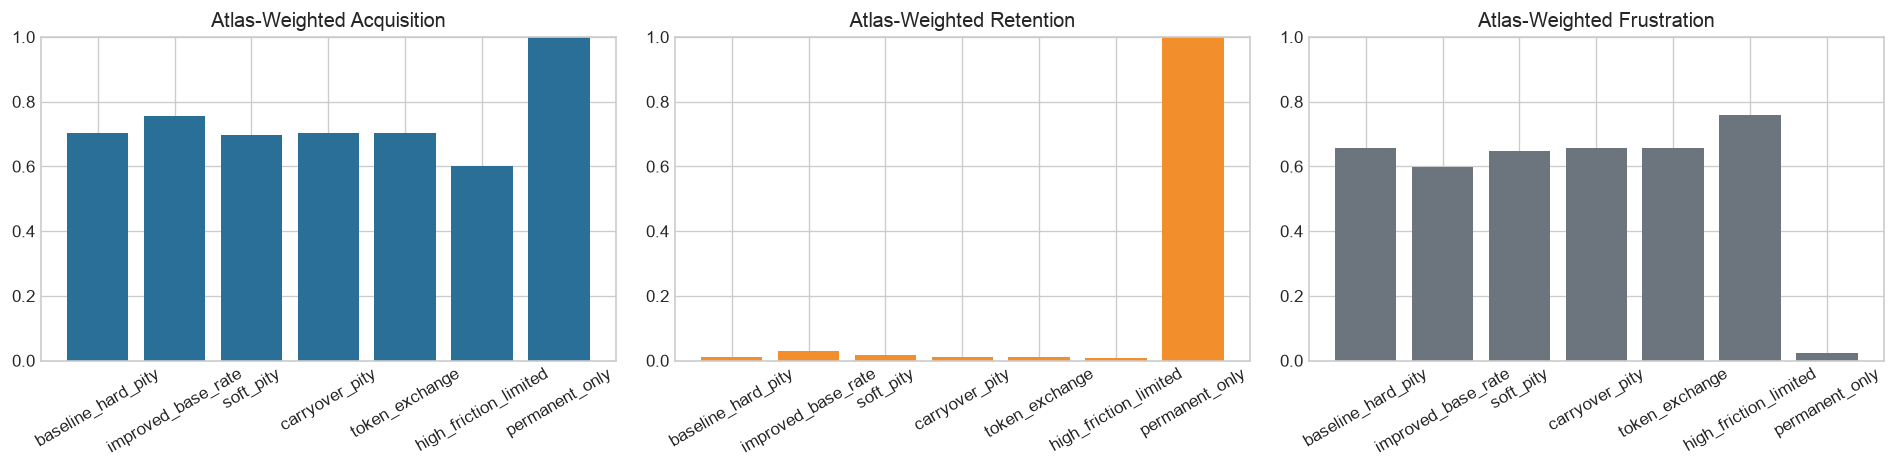

In [18]:
metadata_scenarios = [
    *scenarios,
    Scenario(
        'high_friction_limited',
        base_rate=0.008 / metadata_friction.get('limited_only', 1.0),
        pity_threshold=330,
        retention_multiplier=metadata_friction.get('duplicate_copy_pressure', 1.0),
    ),
    Scenario(
        'permanent_only',
        base_rate=0.008 / (1 - metadata_friction.get('limited_fraction', 0.3)),
        pity_threshold=330,
        retention_multiplier=metadata_friction.get('duplicate_copy_pressure', 1.0),
    ),
]

metadata_summary_rows = []
for scenario in metadata_scenarios:
    metadata_data = simulate_population(scenario, players=5000, seed=42, banners=DEFAULT_BANNERS)
    metadata_summary_rows.append({
        'scenario': scenario.name,
        'acquisition_rate': float((metadata_data['success_banners'] > 0).mean()),
        'avg_retention_probability': float((1.0 - metadata_data['churned']).mean()),
        'avg_frustration': float(metadata_data['mean_frustration'].mean()),
    })

metadata_summary_df = pd.DataFrame(metadata_summary_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)

axes[0].bar(metadata_summary_df['scenario'], metadata_summary_df['acquisition_rate'], color='#2a6f97')
axes[0].set_title('Atlas-Weighted Acquisition')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1)

axes[1].bar(metadata_summary_df['scenario'], metadata_summary_df['avg_retention_probability'], color='#f28e2b')
axes[1].set_title('Atlas-Weighted Retention')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 1)

axes[2].bar(metadata_summary_df['scenario'], metadata_summary_df['avg_frustration'], color='#6c757d')
axes[2].set_title('Atlas-Weighted Frustration')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'atlas_weighted_acquisition_retention.png', bbox_inches='tight')
plt.show()

## 13. Atlas-Weighted Visualization

This figure compares the Atlas-weighted scenario variants so the acquisition-friction and duplicate-copy pressure changes are visible alongside the baseline comparison.